In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data_path = "/content/drive/MyDrive/Last-Mile-Logistics-Auditor/data/"

orders = pd.read_csv(data_path + "olist_orders_dataset.csv")
customers = pd.read_csv(data_path + "olist_customers_dataset.csv")
reviews = pd.read_csv(data_path + "olist_order_reviews_dataset.csv")
order_items = pd.read_csv(data_path + "olist_order_items_dataset.csv")
products = pd.read_csv(data_path + "olist_products_dataset.csv")
translation = pd.read_csv(data_path + "product_category_name_translation.csv")

In [4]:
print(orders.head())
print(customers.head())
print(reviews.head())

print(orders.isnull().sum())
print(customers.isnull().sum())
print(reviews.isnull().sum())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [5]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])


In [6]:
master = (
    orders
    .merge(reviews, on="order_id", how="left")
    .merge(customers, on="customer_id", how="left")
)

print("Duplicate Order IDs:", master.duplicated("order_id").sum())

Duplicate Order IDs: 551


In [7]:
master["delivery_delay"] = (
    master["order_delivered_customer_date"]
    - master["order_estimated_delivery_date"]
).dt.days


In [8]:
def classify(delay):
    if pd.isna(delay):
        return "Not Delivered"
    elif delay <= 0:
        return "On Time"
    elif delay <= 5:
        return "Late"
    else:
        return "Super Late"

master["delivery_status"] = master["delivery_delay"].apply(classify)

In [9]:
products = products.merge(
    translation,
    on="product_category_name",
    how="left"
)


items = order_items.merge(
    products,
    on="product_id",
    how="left"
)


master = master.merge(
    items,
    on="order_id",
    how="left"
)

In [10]:
analysis = master[
    ~master["order_status"].isin(["canceled", "unavailable"])
].copy()

/tmp/ipykernel_468/2201557446.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["delivery_status"] != "On Time").mean() * 100)


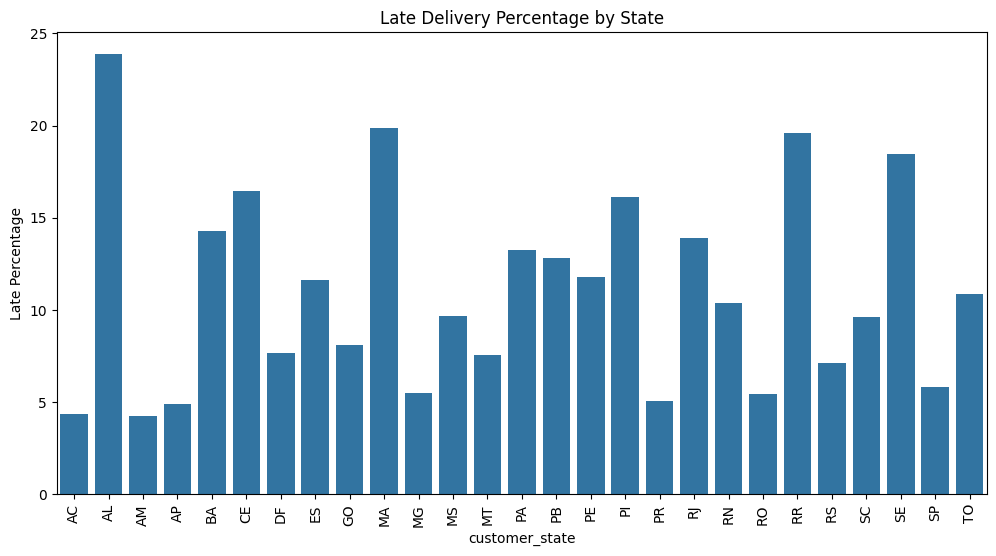

In [11]:
late_by_state = (
    analysis
    .groupby("customer_state")
    .apply(lambda x: (x["delivery_status"] != "On Time").mean() * 100)
    .reset_index(name="Late Percentage")
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=late_by_state,
    x="customer_state",
    y="Late Percentage"
)
plt.xticks(rotation=90)
plt.title("Late Delivery Percentage by State")
plt.show()

delivery_status
Late             2.942577
Not Delivered    1.813827
On Time          4.207410
Super Late       1.736842
Name: review_score, dtype: float64


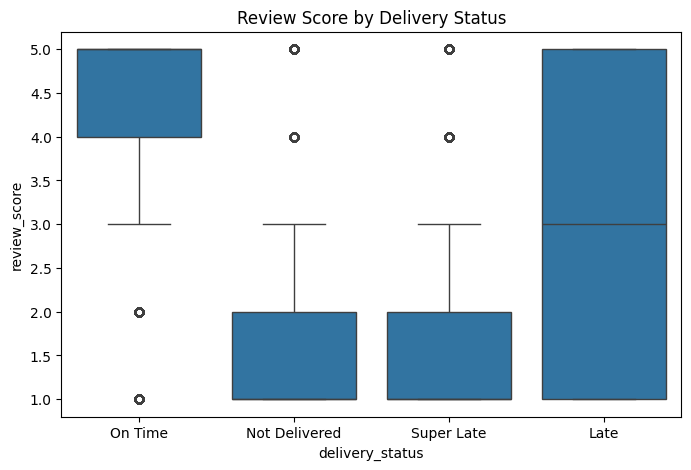

In [12]:
print(
    analysis.groupby("delivery_status")["review_score"].mean()
)

plt.figure(figsize=(8,5))
sns.boxplot(
    data=analysis,
    x="delivery_status",
    y="review_score"
)
plt.title("Review Score by Delivery Status")
plt.show()

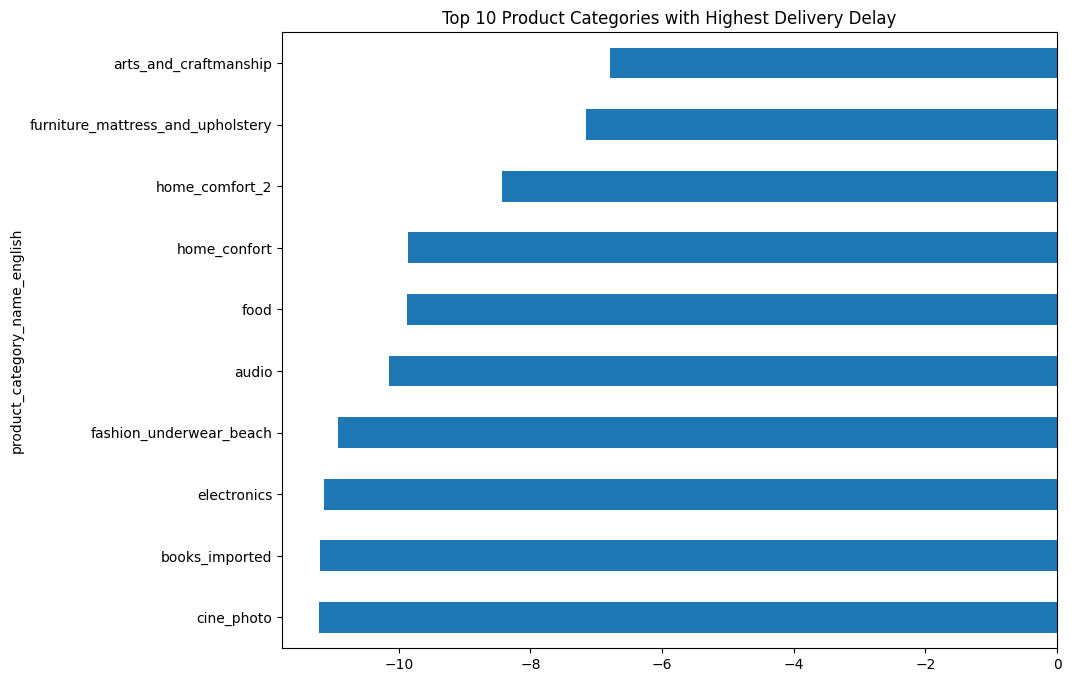

In [13]:
category_delay = (
    analysis
    .groupby("product_category_name_english")["delivery_delay"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,8))
category_delay.tail(10).plot(kind="barh")
plt.title("Top 10 Product Categories with Highest Delivery Delay")
plt.show()

In [14]:
dashboard_data = analysis[[
    "order_id",
    "customer_state",
    "order_status",
    "review_score",
    "delivery_delay",
    "delivery_status",
    "product_category_name_english"
]].copy()

# Remove duplicate rows
dashboard_data = dashboard_data.drop_duplicates()

# Rename columns for Tableau
dashboard_data.rename(columns={
    "customer_state": "State",
    "review_score": "Review Score",
    "delivery_delay": "Delivery Delay (Days)",
    "delivery_status": "Delivery Status",
    "product_category_name_english": "Product Category",
    "order_status": "Order Status"
}, inplace=True)


In [15]:
dashboard_data.to_csv(
    "delivery_performance_dashboard_clean.csv",
    index=False
)

print("\nDataset Shape:", dashboard_data.shape)
print("\nColumns:")
print(dashboard_data.columns.tolist())

print("\nPreview:")
print(dashboard_data.head())



Dataset Shape: (99218, 7)

Columns:
['order_id', 'State', 'Order Status', 'Review Score', 'Delivery Delay (Days)', 'Delivery Status', 'Product Category']

Preview:
                           order_id State Order Status  Review Score  \
0  e481f51cbdc54678b7cc49136f2d6af7    SP    delivered           4.0   
1  53cdb2fc8bc7dce0b6741e2150273451    BA    delivered           4.0   
2  47770eb9100c2d0c44946d9cf07ec65d    GO    delivered           5.0   
3  949d5b44dbf5de918fe9c16f97b45f8a    RN    delivered           5.0   
4  ad21c59c0840e6cb83a9ceb5573f8159    SP    delivered           5.0   

   Delivery Delay (Days) Delivery Status Product Category  
0                   -8.0         On Time       housewares  
1                   -6.0         On Time        perfumery  
2                  -18.0         On Time             auto  
3                  -13.0         On Time         pet_shop  
4                  -10.0         On Time       stationery  


In [16]:
from google.colab import files
files.download("delivery_performance_dashboard_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>